In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df = pd.read_csv('/content/drive/MyDrive/MLProject_Data/WinnipegDataset.txt')
df.head()

,label,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f165,f166,f167,f168,f169,f170,f171,f172,f173,f174
0,1,-13.559,-21.407,-11.4040,-15.248,-11.923,-15.291,-2.1548,-7.8474,-10.0020,...,0.18519,0.72602,5.3333,6.000000,0.29489,9.77780,2.44440,1.67700,0.20988,0.65422
1,1,-12.802,-20.335,-10.3990,-14.132,-11.096,-14.361,-2.4039,-7.5330,-9.9369,...,0.33333,-0.48751,2.1111,0.098765,0.83333,0.33333,0.33333,0.84869,0.50617,-0.18898
2,1,-12.431,-19.902,-10.0740,-13.598,-10.829,-14.048,-2.3566,-7.4717,-9.8283,...,0.25926,0.25298,2.2222,0.172840,0.68889,0.88889,0.66667,1.27300,0.30864,0.10483
3,1,-12.689,-19.529,-10.0280,-13.350,-11.056,-14.014,-2.6611,-6.8396,-9.5006,...,0.16049,0.43750,4.1111,0.320990,0.83333,0.33333,0.33333,1.14910,0.38272,0.41603
4,1,-12.686,-19.278,-9.8185,-13.108,-10.932,-13.939,-2.8675,-6.5919,-9.4594,...,0.18519,0.35000,4.0000,0.444440,0.68889,0.88889,0.66667,1.58110,0.20988,0.50000


# **Data Preprocessing**

 ## check if there is any null values

In [10]:
print(df.isnull().sum().sum())

0


## Handle duplicated records

In [11]:
print(df.duplicated().sum())

0


In [12]:
df =df.drop_duplicates()
print('The new data shape is: ', df.shape)

The new data shape is:  (325834, 175)


## data validation

In [13]:
print('check data type')
df.dtypes.value_counts()

check data type


,count
float64,169
int64,6


## Outliers

In [14]:
colomns=df.columns.drop('label')

In [15]:
Q1 = df[colomns].quantile(0.25)
Q3 = df[colomns].quantile(0.75)
IQR = Q3 - Q1

In [16]:
Q1, Q3, IQR

(f1     -17.84800
 f2     -27.11900
 f3     -17.56300
 f4     -21.44900
 f5     -16.98900
           ...   
 f170     0.00000
 f171     0.00000
 f172     0.00000
 f173     0.50617
 f174     0.35714
 Name: 0.25, Length: 174, dtype: float64,
 f1     -11.78600
 f2     -20.38700
 f3     -13.42700
 f4     -15.65000
 f5     -11.73500
           ...   
 f170     0.33333
 f171     0.33333
 f172     0.84869
 f173     1.00000
 f174     1.00000
 Name: 0.75, Length: 174, dtype: float64,
 f1      6.06200
 f2      6.73200
 f3      4.13600
 f4      5.79900
 f5      5.25400
          ...   
 f170    0.33333
 f171    0.33333
 f172    0.84869
 f173    0.49383
 f174    0.64286
 Length: 174, dtype: float64)

In [17]:
upper = Q3 + (1.5 * IQR)
lower = Q1 - (1.5 * IQR)
upper, lower

(f1      -2.693000
 f2     -10.289000
 f3      -7.223000
 f4      -6.951500
 f5      -3.854000
           ...    
 f170     0.833325
 f171     0.833325
 f172     2.121725
 f173     1.740745
 f174     1.964290
 Length: 174, dtype: float64,
 f1     -26.941000
 f2     -37.217000
 f3     -23.767000
 f4     -30.147500
 f5     -24.870000
           ...    
 f170    -0.499995
 f171    -0.499995
 f172    -1.273035
 f173    -0.234575
 f174    -0.607150
 Length: 174, dtype: float64)

In [18]:
outliers = (df[colomns] < lower) | (df[colomns] > upper)
outliers

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f165,f166,f167,f168,f169,f170,f171,f172,f173,f174
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325829,True,True,True,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
325830,True,True,True,True,True,True,False,False,False,False,...,False,False,False,True,True,True,True,True,False,False
325831,True,False,True,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
325832,True,True,True,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
outliers10 = ((df[colomns] < lower) | (df[colomns] > upper)).sum()
outliers10.sort_values(ascending=False).head(10)

,0
f75,40730
f124,39100
f122,38664
f95,38492
f74,38487
f92,37691
f93,37560
f96,34572
f160,33874
f162,33862


In [20]:
numcols_outliers = (outliers10 > 0).sum()
numcols_outliers

np.int64(167)

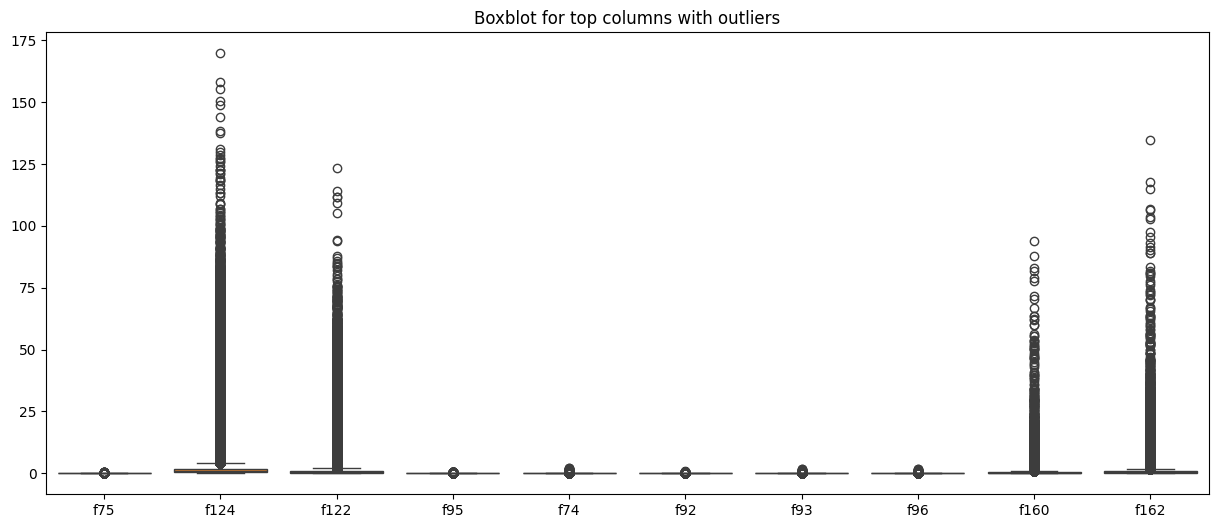

In [21]:

plt.figure(figsize=(15,6))
top_outliers = outliers10.sort_values(ascending=False).head(10).index
sns.boxplot(data=df[top_outliers])
plt.title('Boxblot for top columns with outliers')
plt.show()

## Featuers Selection

In [22]:
x = df.drop('label', axis=1)
y = df['label']-1


In [23]:

corr=x.corr().abs()
remove_columns=set()

for i in range(len(corr.columns)):
  for j in range(i):
    if corr.iloc[i,j]>=0.95:
      col1=corr.columns[i]
      col2=corr.columns[j]

      if abs(x[col1].corr(y))<abs(x[col2].corr(y)):
        remove_columns.add(col1)
      else:
         remove_columns.add(col2)
x=x.drop(columns=remove_columns)
print(x.shape[1])
df=pd.concat([x,y],axis=1)
x.head()


100


,f3,f8,f9,f10,f13,f14,f17,f19,f20,f21,...,f162,f163,f164,f166,f167,f168,f169,f170,f173,f174
0,-11.4040,-7.8474,-10.0020,0.04239,0.35631,0.058490,0.51934,-0.62424,-0.81493,-0.70844,...,2.44440,1.11110,1.8310,0.72602,5.3333,6.000000,0.29489,9.77780,0.20988,0.65422
1,-10.3990,-7.5330,-9.9369,0.22842,0.34295,0.060525,0.50796,-0.57229,-0.74854,-0.64839,...,1.33330,1.11110,1.2149,-0.48751,2.1111,0.098765,0.83333,0.33333,0.50617,-0.18898
2,-10.0740,-7.4717,-9.8283,0.44978,0.34489,0.061731,0.49870,-0.53347,-0.70253,-0.58846,...,0.77778,0.77778,1.3689,0.25298,2.2222,0.172840,0.68889,0.88889,0.30864,0.10483
3,-10.0280,-6.8396,-9.5006,0.66378,0.32760,0.067825,0.47717,-0.50405,-0.66998,-0.52543,...,0.77778,0.77778,1.8892,0.43750,4.1111,0.320990,0.83333,0.33333,0.38272,0.41603
4,-9.8185,-6.5919,-9.4594,0.83143,0.31701,0.069483,0.47476,-0.50314,-0.68221,-0.50731,...,1.66670,1.00000,1.7351,0.35000,4.0000,0.444440,0.68889,0.88889,0.20988,0.50000


In [24]:

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)



## Robust Scaler

In [25]:
scaler = RobustScaler()

X_train = scaler.fit_transform(x_train)
X_val = scaler.transform(x_val)
X_test = scaler.transform(x_test)

X_train_sc = pd.DataFrame(X_train, columns=x_train.columns)
X_val_sc = pd.DataFrame(X_val, columns=x_val.columns)
X_test_sc = pd.DataFrame(X_test, columns=x_test.columns)


# **Unsupervised Algorithm (k-means Clustring)**

#### Determine the optimal number clusters (silhouette score)

In [26]:
def silhouette_inertia(data ,max_k):
    best_k = -1
    best_accuracy = -1
    silhouette_scores = []
    for k in range (2, max_k):
      kmeans = KMeans(n_clusters= k, random_state= 42).fit_predict(data)


      silhouette_avg =  silhouette_score(data, kmeans)
      silhouette_scores.append(silhouette_avg)
      if (silhouette_avg > best_accuracy):
        best_accuracy = silhouette_avg
        best_k = k


    plt.plot(range (2, max_k) , silhouette_scores, 'o-')
    plt.xlabel('Number Of Clusters')
    plt.ylabel('silhouette score')
    plt.grid(True)
    plt.show()
    return best_k

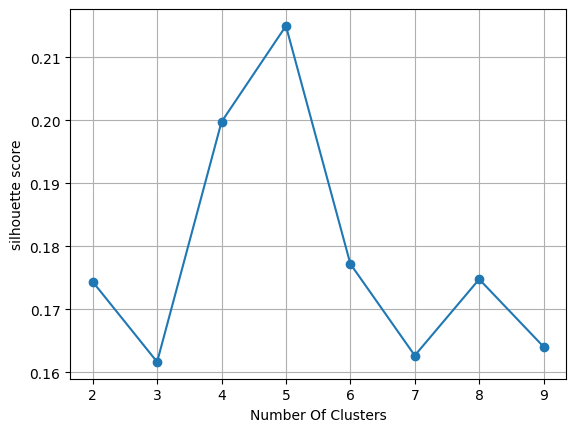

In [29]:
data= df.drop('label', axis=1 )

# standardise data
scalar = StandardScaler()
x_scaled = scalar.fit_transform(data)

index = np.random.choice(x_scaled.shape[0], 6000, replace= False)
sample_data = x_scaled[index]
best_k = silhouette_inertia(sample_data, 10)

#### k-means clustring

In [30]:

model = KMeans(n_clusters= best_k , init='random', random_state= 42 )
labels = model.fit_predict(x_scaled)

true_y= df['label']
y_pred = labels


ari = adjusted_rand_score(true_y, y_pred)
print(f'Adjusted rand score: {ari}')

Adjusted rand score: 0.708791472287861


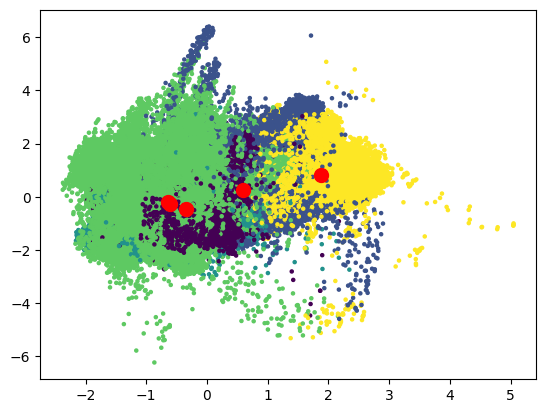

In [31]:
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=labels , s= 5, cmap= 'viridis')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s= 100, c= 'red')
plt.show()

# **Supervised Algorithms**

## ***XGboost***

In [32]:
xgb_classifier = xgb.XGBClassifier(random_state=42)

xgb_classifier.fit(x_train , y_train)

y_pred_xgb = xgb_classifier.predict(x_val)

val_accuracy = accuracy_score(y_val, y_pred_xgb)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_xgb))

Validation Accuracy: 0.9978

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5874
           1       1.00      1.00      1.00       540
           2       1.00      1.00      1.00     11351
           3       1.00      1.00      1.00     11110
           4       1.00      1.00      1.00      7067
           5       1.00      1.00      1.00     12761
           6       0.96      0.98      0.97       172

    accuracy                           1.00     48875
   macro avg       0.99      0.99      0.99     48875
weighted avg       1.00      1.00      1.00     48875



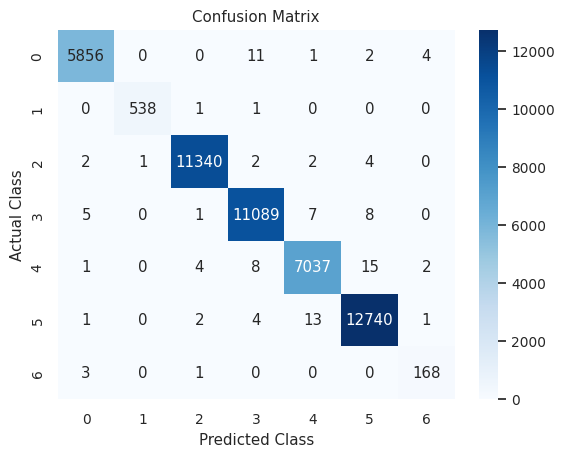

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

c_xgb_v = confusion_matrix(y_val, y_pred_xgb)
class_names = sorted(y_val.unique())
cm_df = pd.DataFrame(c_xgb_v, index=class_names, columns=class_names)

sns.set(font_scale=0.9)
sns.heatmap(cm_df, annot=True ,fmt='g', cmap='Blues')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix')
plt.show()

In [34]:

param_grid = {

    'n_estimators': [150, 250, 350],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 6 ],
    'subsample': [ 0.85, 1.0],
    'colsample_bytree': [0.85, 1.0]

}

xgb_model = xgb.XGBClassifier(random_state=42, objective ='multi:softmax' )

random_s = RandomizedSearchCV(xgb_model, param_grid, cv=2, scoring="accuracy", n_iter=10, n_jobs=-1, verbose=1, random_state=42)
random_s.fit(x_train, y_train)

best_xgb = random_s.best_estimator_

print("Best Parameters:", random_s.best_params_)
print("Best Accuracy:", random_s.best_score_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 350, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.85}
Best Accuracy: 0.997071241417131


Test Accuracy: 0.9982

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5875
           1       1.00      1.00      1.00       539
           2       1.00      1.00      1.00     11351
           3       1.00      1.00      1.00     11110
           4       1.00      1.00      1.00      7068
           5       1.00      1.00      1.00     12762
           6       0.97      0.99      0.98       171

    accuracy                           1.00     48876
   macro avg       0.99      1.00      1.00     48876
weighted avg       1.00      1.00      1.00     48876


Confusion Matrix:



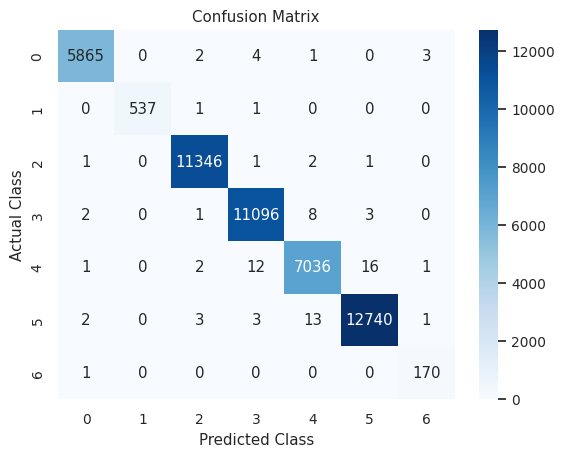

In [35]:
y_pred_xgb = best_xgb.predict(x_test)

test_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")

c_xgb = confusion_matrix(y_test, y_pred_xgb)
class_names = sorted(y_test.unique())
cm_df = pd.DataFrame(c_xgb, index=class_names, columns=class_names)

sns.set(font_scale=0.9)
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix')
plt.show()

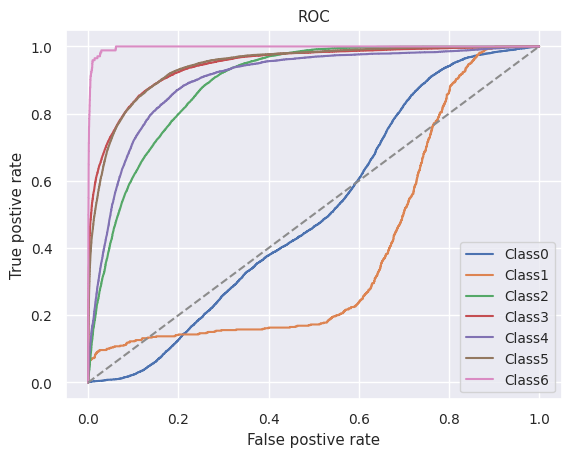

In [37]:
y_test_b = label_binarize(y_test,classes=np.unique(y_test))
y_pred= xgb_classifier.predict_proba(X_test_sc)

for i in range (y_test_b.shape[1]):
   fpr,tpr,p=roc_curve(y_test_b[:,i],y_pred[:,i])
   plt.plot(fpr,tpr,label=f'Class{i}')

plt.plot([0,1],[0,1],'--')

plt.title('ROC')
plt.xlabel('False postive rate')
plt.ylabel('True postive rate')
plt.legend()
plt.show()

## ***Random Forest***

In [38]:
X_corr = x
y_corr = y

x_train_corr, x_temp_corr, y_train_corr, y_temp_corr = train_test_split(
    X_corr, y_corr, test_size=0.30, random_state=42, stratify=y_corr
)

x_val_corr, x_test_corr, y_val_corr, y_test_corr = train_test_split(
    x_temp_corr, y_temp_corr, test_size=0.50, random_state=42, stratify=y_temp_corr
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf.fit(x_train_corr, y_train_corr)

y_pred = rf.predict(x_test_corr)
rf_accuracy = accuracy_score(y_test_corr, y_pred)

print("Test Accuracy:", rf_accuracy)
print("Classification report -Random Forest-", classification_report(y_test_corr, y_pred))

y_pred_val = rf.predict(x_val_corr)
val_accuracy = accuracy_score(y_val_corr, y_pred_val)

print("Validation Accuracy:", val_accuracy)
print("OOB Score :", rf.oob_score_)

Test Accuracy: 0.9960103118094771
Classification report -Random Forest-               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5875
           1       1.00      1.00      1.00       539
           2       1.00      1.00      1.00     11351
           3       1.00      1.00      1.00     11110
           4       0.99      0.99      0.99      7068
           5       1.00      1.00      1.00     12762
           6       0.97      0.97      0.97       171

    accuracy                           1.00     48876
   macro avg       0.99      0.99      0.99     48876
weighted avg       1.00      1.00      1.00     48876

Validation Accuracy: 0.9964808184143222
OOB Score : 0.996203136577474


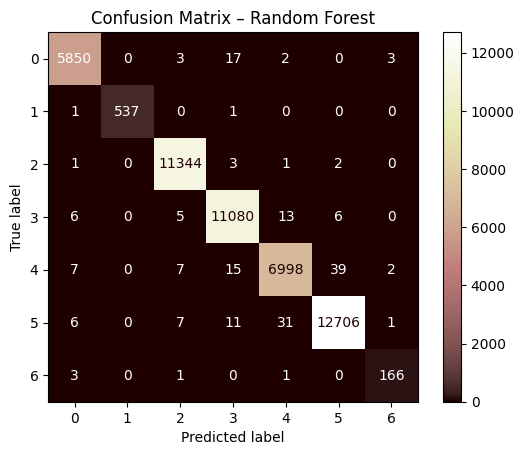

In [39]:
sns.reset_defaults()
cm_rf = confusion_matrix(y_test_corr, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=np.unique(y_test_corr)
)

disp.plot(values_format='d', cmap='pink')
plt.title("Confusion Matrix – Random Forest")
plt.show()


**Comparison between Supervised algorithms accuracies**

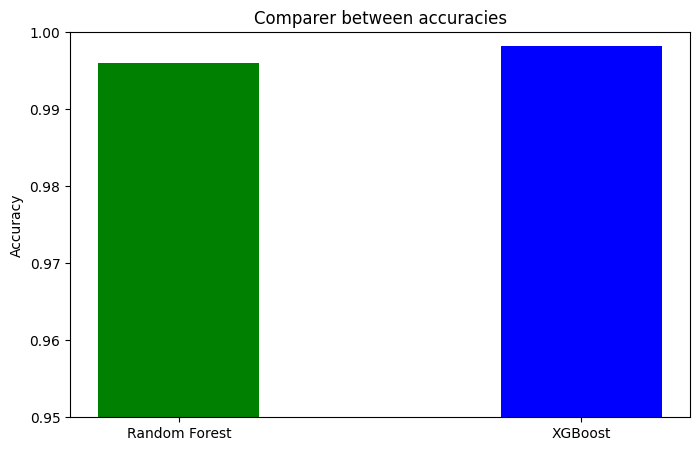

In [40]:
plt.figure(figsize=(8,5))
model = ['Random Forest', 'XGBoost']
accuracy = [rf_accuracy, test_accuracy]
plt.bar(model, accuracy,width=0.4 ,color=['green', 'blue'])
plt.ylabel('Accuracy')
plt.ylim(0.95, 1.0)
plt.title('Comparer between accuracies')
plt.show()